In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch
from PIL import Image
import torch.backends.cudnn as cudnn

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torchvision
from torchvision import datasets, models, transforms

import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy

In [2]:
# Definir transformaciones de datos para entrenamiento, validación y prueba
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [3]:
data_dir = os.path.join('..', '..', 'data')

# Cargar dataset
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val', 'test']}

# Se usa num_workers=0 para Windows para prevenir errores de multiprocesamiento en Jupyter
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=0) for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print(f"Clases cargadas: {class_names}")
print(f"Tamaños del dataset: {dataset_sizes}")

Clases cargadas: ['gray_leaf_spot', 'healthy', 'magnesium_deficiency']
Tamaños del dataset: {'train': 1260, 'val': 270, 'test': 270}


In [4]:
# ---------------------------------
# Arquitectura de la red neuronal
# ---------------------------------

# Descargar ResNet-18 preentrenada en ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congelamos las capas internas para evitar que se actualicen durante el entrenamiento
for param in model.parameters():
    param.requires_grad = False

# Cambiamos la última capa (fully connected) para que tenga el número de clases de nuestro dataset
num_ftrs = model.fc.in_features

# len(class_names) es el número de clases en nuestro dataset
model.fc = nn.Linear(num_ftrs, len(class_names))

# Mover el modelo a la GPU si está disponible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [5]:
# Función de pérdida estándar para clasificación: CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Optimizador: solo actualizamos los parámetros de la última capa (model.fc)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [6]:
num_epochs = 15

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)
    
    # Cada epoch tiene una fase de entrenamiento y una de validación
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Activa el modo de entrenamiento (aplica Dropout, etc.)
        else:
            model.eval()   # Activa el modo de evaluación (congela el modelo)
            
        running_loss = 0.0
        running_corrects = 0
        
        # Iterar sobre los lotes (batches) de imágenes del DataLoader
        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Limpiar los gradientes del optimizador
            optimizer.zero_grad()
            
            # Forward: El modelo intenta adivinar qué enfermedad es
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                # Backward + Optimizar solo si estamos en fase de entrenamiento
                if phase == 'train':
                    loss.backward()  # Calcula el error
                    optimizer.step() # Ajusta los pesos matemáticos
            
            # Estadísticas
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Epoch 1/15
----------
train Loss: 0.7597 Acc: 0.6532
val Loss: 0.4225 Acc: 0.8407
Epoch 2/15
----------
train Loss: 0.5532 Acc: 0.7690
val Loss: 0.3262 Acc: 0.8741
Epoch 3/15
----------
train Loss: 0.4708 Acc: 0.7984
val Loss: 0.2572 Acc: 0.9148
Epoch 4/15
----------
train Loss: 0.4610 Acc: 0.8040
val Loss: 0.2904 Acc: 0.8852
Epoch 5/15
----------
train Loss: 0.5286 Acc: 0.7786
val Loss: 0.2393 Acc: 0.9111
Epoch 6/15
----------
train Loss: 0.4843 Acc: 0.8016
val Loss: 0.2269 Acc: 0.9074
Epoch 7/15
----------
train Loss: 0.4490 Acc: 0.8222
val Loss: 0.2319 Acc: 0.9148
Epoch 8/15
----------
train Loss: 0.4805 Acc: 0.8127
val Loss: 0.2038 Acc: 0.9333
Epoch 9/15
----------
train Loss: 0.4540 Acc: 0.8262
val Loss: 0.2791 Acc: 0.8852
Epoch 10/15
----------
train Loss: 0.4765 Acc: 0.8079
val Loss: 0.2066 Acc: 0.9185
Epoch 11/15
----------
train Loss: 0.4381 Acc: 0.8270
val Loss: 0.2319 Acc: 0.9037
Epoch 12/15
----------
train Loss: 0.4089 Acc: 0.8341
val Loss: 0.2624 Acc: 0.9000
Epoch 13/15
-

In [7]:
# Guardar el modelo entrenado
torch.save(model.state_dict(), 'resnet18_corn_disease.pth')
print("Modelo guardado como 'resnet18_corn_disease.pth'")

Modelo guardado como 'resnet18_corn_disease.pth'


Evaluando el modelo utilizando: cpu

              REPORTE DE EVALUACIÓN FINAL
                      precision    recall  f1-score   support

      gray_leaf_spot       0.99      0.99      0.99        90
             healthy       0.93      0.87      0.90        90
magnesium_deficiency       0.88      0.93      0.90        90

            accuracy                           0.93       270
           macro avg       0.93      0.93      0.93       270
        weighted avg       0.93      0.93      0.93       270

Accuracy en el conjunto de prueba: 92.96%


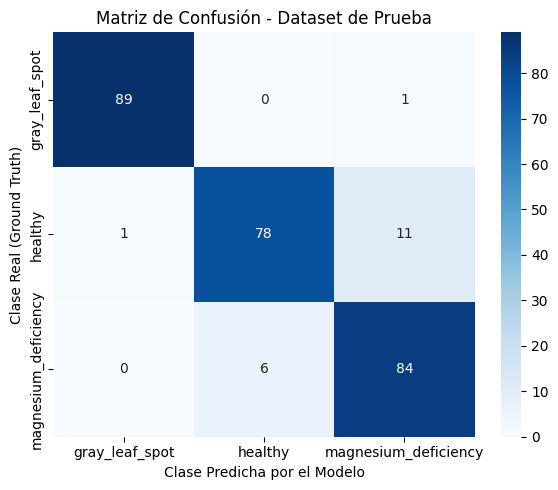

In [11]:
# ----------------------------------------
# 1. CONFIGURACIÓN DEL ENTORNO Y HARDWARE
# ----------------------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Evaluando el modelo utilizando: {device}")

# ------------------------------------------
# 2. RECONSTRUIR LA ARQUITECTURA DEL MODELO
# ------------------------------------------

# Debes declarar exactamente la misma estructura
model = models.resnet18(weights=None) # No necesitamos ImageNet porque cargaremos tus pesos
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

# ------------------------------------------
# 3. CARGAR LOS PESOS ENTRENADOS
# ------------------------------------------

# Cargar los pesos del modelo entrenado
model.load_state_dict(torch.load('resnet18_corn_disease.pth', map_location=device))
model = model.to(device)

# Cambiar el modelo a modo evaluación
model.eval()

# ----------------------------------------------
# 4. EVALUAR EL MODELO EN EL CONJUNTO DE PRUEBA
# ----------------------------------------------
all_preds = []
all_labels = []

# Iterar sobre el conjunto de prueba
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convertir a numpy arrays para sklearn
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ----------------------------------------------
# 5. MÉTRICAS DE EVALUACIÓN
# ----------------------------------------------
print("\n" + "="*50)
print("              REPORTE DE EVALUACIÓN FINAL")
print("="*50)

# Reporte de clasificación
print(classification_report(all_labels, all_preds, target_names=class_names))

# Calcular el Accuracy
accuracy = np.mean(all_preds == all_labels) * 100
print(f"Accuracy en el conjunto de prueba: {accuracy:.2f}%")

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Dataset de Prueba')
plt.ylabel('Clase Real (Ground Truth)')
plt.xlabel('Clase Predicha por el Modelo')
plt.tight_layout()
plt.show()



In [12]:
def predict_image(image_path, model, data_transforms, class_names, device):
    """
    Recibe la ruta de una foto, la procesa y devuelve el diagnóstico del modelo.
    """
    # 1. Cargar la imagen en modo RGB
    image = Image.open(image_path).convert('RGB')
    
    # 2. Aplicar EXACTAMENTE las mismas transformaciones de validación/prueba
    # Usamos 'val' o 'test' porque no queremos recortes aleatorios aquí
    transformed_image = data_transforms['val'](image)
    
    # 3. Añadir la dimensión del lote (Batch Dimension)
    # Pasa de tener forma [3, 224, 224] a [1, 3, 224, 224]
    transformed_image = transformed_image.unsqueeze(0)
    
    # 4. Mover la imagen al mismo dispositivo que el modelo (GPU o CPU)
    transformed_image = transformed_image.to(device)
    
    # 5. Modo evaluación e inferencia segura
    model.eval()
    with torch.no_grad():
        outputs = model(transformed_image)
        
        # Obtener las probabilidades si quieres saber qué tan seguro está el modelo
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        
        # Obtener el índice de la clase con el valor más alto
        _, predicted = torch.max(outputs, 1)
        
    # Extraer el nombre de la clase y el porcentaje de certeza
    predicted_class = class_names[predicted.item()]
    confidence = probabilities[0][predicted.item()].item() * 100

    print(f"Predicción: {predicted_class} ({confidence:.2f}% de certeza)")
    
    # Devolvemos la predicción y la imagen original (PIL) para poder mostrarla en pantalla si deseas
    return predicted_class, image


In [16]:
# Ejemplo de uso real
#ruta_foto_maiz = "../../data/test/gray_leaf_spot/gray_leaf_spot_maize_field_real_14354404.jpg"
ruta_foto_maiz = "../../data/test/magnesium_deficiency/magnesium_deficiency_corn_leaf_roboflow_real_11136454.jpg"

clase_resultado, img = predict_image(
    image_path=ruta_foto_maiz, 
    model=model, 
    data_transforms=data_transforms, # Tu diccionario de transformaciones
    class_names=class_names, 
    device=device
)

# Si estás en Jupyter y quieres ver la foto que acabas de evaluar:
# img.show() o usando matplotlib

Predicción: magnesium_deficiency (98.32% de certeza)
